<a href="https://colab.research.google.com/github/Spandana2704/ML/blob/main/Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1.Comparing Single vs. Ensemble Classifiers**

Task:
Write a program that demonstrates the advantage of ensemble learning compared to a single classifier.

Apply a Decision Tree and a Random Forest (RF) classifier on a given dataset.

Compare their performance using evaluation metrics such as accuracy, precision, recall,and F1-score.

Explore the effect of changing the number of estimators (decision trees) in Random Forest. Write clear observations with justification.

Intermediate Questions:

1. What differences do you observe between the Decision Tree and Random Forest
results?
2. How does increasing the number of estimators affect performance and stability?
3. Why does Random Forest generally perform better than a single Decision Tree?

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df=pd.read_csv('/content/titanic_train.csv')
df=df.drop('Ticket',axis=1)
df=df.drop('Cabin',axis=1)
df=df.drop('Embarked',axis=1)
df=df.drop('Name',axis=1)
df=df.drop('PassengerId',axis=1)
df['Age'] = df['Age'].fillna(df['Age'].median())
X = df.drop('Survived',axis=1)
y = df['Survived']
le = LabelEncoder()
X['Sex'] = le.fit_transform(X['Sex'])
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df2 = pd.read_csv('car_price_prediction.csv')

df2 = df2.drop(['id', 'marka', 'seri', 'model'], axis=1)
df2 = df2.dropna()

numerical_columns = ['motor_hacmi', 'motor_gucu', 'degisen_sayisi', 'boyali_sayisi']
for col in numerical_columns:
    df2[col] = df2[col].fillna(df2[col].median())

X2 = df2.drop('fiyat', axis=1)
y2 = df2['fiyat']

le = LabelEncoder()
categorical_columns = ['vites_tipi', 'yakit_tipi', 'kasa_tipi', 'renk', 'kimden']

for col in categorical_columns:
    X2[col] = le.fit_transform(X2[col])

x_train2, x_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3, random_state=0)

In [4]:
[col for col in df2.columns if df2[col].isnull().sum()>0]

[]

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.ensemble import VotingClassifier
from sklearn import metrics
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [6]:
clf=DecisionTreeClassifier()
clf=clf.fit(x_train,y_train)
clf_pred=clf.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test,clf_pred))
print("Recall:",metrics.recall_score(y_test,clf_pred))
print("Precision:",metrics.precision_score(y_test,clf_pred))
print("F1 Score:",metrics.f1_score(y_test,clf_pred))

Accuracy: 0.8022388059701493
Recall: 0.68
Precision: 0.7640449438202247
F1 Score: 0.7195767195767195


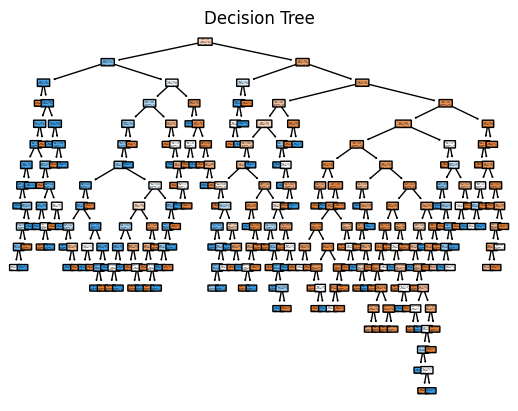

In [7]:
plot_tree(clf,filled=True,rounded=True,feature_names=x_train.columns,class_names=['0','1'])
plt.title('Decision Tree')
plt.show()

In [8]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)

In [9]:
print("Accuracy:",metrics.accuracy_score(y_test,rf_pred))
print("Recall:",metrics.recall_score(y_test,rf_pred))
print("Precision:",metrics.precision_score(y_test,rf_pred))
print("F1 Score:",metrics.f1_score(y_test,rf_pred))

Accuracy: 0.8283582089552238
Recall: 0.73
Precision: 0.7934782608695652
F1 Score: 0.7604166666666666


In [10]:
rf=RandomForestClassifier(n_estimators=50,random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test,rf_pred))
print("Recall:",metrics.recall_score(y_test,rf_pred))
print("Precision:",metrics.precision_score(y_test,rf_pred))
print("F1 Score:",metrics.f1_score(y_test,rf_pred))

Accuracy: 0.835820895522388
Recall: 0.75
Precision: 0.7978723404255319
F1 Score: 0.7731958762886598


In [11]:
rf=RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test,rf_pred))
print("Recall:",metrics.recall_score(y_test,rf_pred))
print("Precision:",metrics.precision_score(y_test,rf_pred))
print("F1 Score:",metrics.f1_score(y_test,rf_pred))

Accuracy: 0.8208955223880597
Recall: 0.73
Precision: 0.776595744680851
F1 Score: 0.7525773195876289


In [12]:
rf=RandomForestClassifier(n_estimators=500,random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test,rf_pred))
print("Recall:",metrics.recall_score(y_test,rf_pred))
print("Precision:",metrics.precision_score(y_test,rf_pred))
print("F1 Score:",metrics.f1_score(y_test,rf_pred))

Accuracy: 0.8171641791044776
Recall: 0.71
Precision: 0.7802197802197802
F1 Score: 0.743455497382199


In [13]:

rf=RandomForestClassifier(n_estimators=500,max_depth=6,min_samples_split=4,random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test,rf_pred))
print("Recall:",metrics.recall_score(y_test,rf_pred))
print("Precision:",metrics.precision_score(y_test,rf_pred))
print("F1 Score:",metrics.f1_score(y_test,rf_pred))

Accuracy: 0.8208955223880597
Recall: 0.72
Precision: 0.782608695652174
F1 Score: 0.75


In [14]:
rf=RandomForestClassifier(n_estimators=100,max_depth=6,min_samples_split=4,random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test,rf_pred))
print("Recall:",metrics.recall_score(y_test,rf_pred))
print("Precision:",metrics.precision_score(y_test,rf_pred))
print("F1 Score:",metrics.f1_score(y_test,rf_pred))

Accuracy: 0.8208955223880597
Recall: 0.74
Precision: 0.7708333333333334
F1 Score: 0.7551020408163265


In [15]:
rf=RandomForestClassifier(n_estimators=200,max_depth=6,min_samples_split=4,random_state=42)
rf.fit(x_train,y_train)
rf_pred=rf.predict(x_test)
print("Accuracy:",metrics.accuracy_score(y_test,rf_pred))
print("Recall:",metrics.recall_score(y_test,rf_pred))
print("Precision:",metrics.precision_score(y_test,rf_pred))
print("F1 Score:",metrics.f1_score(y_test,rf_pred))

Accuracy: 0.8208955223880597
Recall: 0.73
Precision: 0.776595744680851
F1 Score: 0.7525773195876289


**2.Implementing Simple Ensemble Techniques**

Task:

Write a program that demonstrates the use of simple ensemble techniques: Max Voting, Average Voting, and Weighted Average Voting  (assign weights based on each model’s performance).

Apply these techniques on a suitable dataset and compare results.

Intermediate Questions:
1. How do the results vary between max voting, average voting, and weighted voting?
2. What is the role of weights in improving ensemble predictions?
3. Which base classifiers combine most effectively under each voting scheme?

In [16]:
#max voting
#predictions=np.array([pred1,pred2,pred3])
#max_vote_pred=np.apply_along_axis(lambda x:np.bincount(x).argmax(),axis=0,arr=predictions)

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

model1 = LinearRegression()
model1.fit(x_train2, y_train2)
pred1 = model1.predict(x_test2)
r21 = r2_score(y_test2, pred1)

del model1

model2 = DecisionTreeRegressor(random_state=42)
model2.fit(x_train2, y_train2)
pred2 = model2.predict(x_test2)
r22 = r2_score(y_test2, pred2)

del model2

model3 = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
model3.fit(x_train2, y_train2)
pred3 = model3.predict(x_test2)
r23 = r2_score(y_test2, pred3)

del model3

In [18]:
avg_vote_pred = (pred1 + pred2 + pred3) / 3

weights = np.array([r21, r22, r23])
weights = weights / np.sum(weights)
weighted_vote_pred = (pred1 * weights[0] + pred2 * weights[1] + pred3 * weights[2])

def evaluate(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print("R²:", round(r2_score(y_true, y_pred), 3))
    print("MAE:", round(mean_absolute_error(y_true, y_pred), 3))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 3))

evaluate(y_test2, avg_vote_pred, "Average Voting")
evaluate(y_test2, weighted_vote_pred, "Weighted Average Voting")


=== Average Voting ===
R²: -0.952
MAE: 320189.308
RMSE: 4030115.55

=== Weighted Average Voting ===
R²: -5.994
MAE: 314030.867
RMSE: 7628340.28


In [19]:
avg_vote_pred = (pred1 + pred2 + pred3) / 3

weights = np.array([r21, r22, r23])
scores = np.array([max(0, r21), max(0, r22), max(0, r23)])
weights = scores / np.sum(scores)
weighted_vote_pred = (pred1 * weights[0] + pred2 * weights[1] + pred3 * weights[2])

def evaluate(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print("R²:", round(r2_score(y_true, y_pred), 3))
    print("MAE:", round(mean_absolute_error(y_true, y_pred), 3))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 3))

evaluate(y_test2, avg_vote_pred, "Average Voting")
evaluate(y_test2, weighted_vote_pred, "Weighted Average Voting")


=== Average Voting ===
R²: -0.952
MAE: 320189.308
RMSE: 4030115.55

=== Weighted Average Voting ===
R²: 0.146
MAE: 581645.702
RMSE: 2665349.264


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train2)
x_test_scaled = scaler.transform(x_test2)

In [21]:
model1 = LinearRegression()
model1.fit(x_train_scaled, y_train2)
pred1 = model1.predict(x_test_scaled)
r21 = r2_score(y_test2, pred1)

del model1

model2 = DecisionTreeRegressor(random_state=42)
model2.fit(x_train_scaled, y_train2)
pred2 = model2.predict(x_test_scaled)
r22 = r2_score(y_test2, pred2)

del model2

model3 = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
model3.fit(x_train_scaled, y_train2)
pred3 = model3.predict(x_test_scaled)
r23 = r2_score(y_test2, pred3)

del model3

In [22]:
avg_vote_pred = (pred1 + pred2 + pred3) / 3

weights = np.array([r21, r22, r23])
scores = np.array([max(0, r21), max(0, r22), max(0, r23)])
weights = scores / np.sum(scores)
weighted_vote_pred = (pred1 * weights[0] + pred2 * weights[1] + pred3 * weights[2])

def evaluate(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print("R²:", round(r2_score(y_true, y_pred), 3))
    print("MAE:", round(mean_absolute_error(y_true, y_pred), 3))
    print("RMSE:", round(np.sqrt(mean_squared_error(y_true, y_pred)), 3))

evaluate(y_test2, avg_vote_pred, "Average Voting")
evaluate(y_test2, weighted_vote_pred, "Weighted Average Voting")


=== Average Voting ===
R²: -0.952
MAE: 320320.129
RMSE: 4030133.39

=== Weighted Average Voting ===
R²: 0.146
MAE: 581645.702
RMSE: 2665349.264


**3.Hard Voting vs. Soft Voting Classifiers**

Task:

Write a program to show the difference between Hard Voting and Soft Voting classifiers in ensemble learning using multiple base learners (e.g., Decision Tree, Logistic Regression, and KNN).

Intermediate Questions:

1. What is the main difference in prediction mechanisms between hard and soft
voting?
2. In which situations does soft voting outperform hard voting?
3. How does the probability calibration of base classifiers influence soft voting?

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

estimators = [
    ('LR', LogisticRegression(max_iter=500)),
    ('CLF', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('DTC', DecisionTreeClassifier(random_state=42))
]

hard_voting = VotingClassifier(estimators=estimators, voting='hard')
hard_voting.fit(x_train_scaled, y_train)
y_pred = hard_voting.predict(x_test_scaled)
hard_score = metrics.accuracy_score(y_test, y_pred)
print("Hard Voting Score:", hard_score)

soft_voting = VotingClassifier(estimators=estimators, voting='soft')
soft_voting.fit(x_train_scaled, y_train)
y_pred = soft_voting.predict(x_test_scaled)
soft_score = metrics.accuracy_score(y_test, y_pred)
print("Soft Voting Score:", soft_score)

weighted_voting = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=[1, 3, 2]
)

weighted_voting.fit(x_train_scaled, y_train)
y_pred = weighted_voting.predict(x_test_scaled)
weighted_score = metrics.accuracy_score(y_test, y_pred)
print("Weighted Voting Score:", weighted_score)


Hard Voting Score: 0.835820895522388
Soft Voting Score: 0.832089552238806
Weighted Voting Score: 0.832089552238806


**4.Exploring Bagging Technique (Random Forest)**

Task:

Write a program to explore the Bagging technique using the RandomForestClassifier on a suitable dataset.Experiment with parameters such as number of estimators, maximum depth, and random state.

Write detailed observations and justify the changes in model performance.

Intermediate Questions:

1. How do different values of n_estimators and max_depth affect model performance?
2. What does Bagging achieve in terms of variance and bias reduction?
3. How does Random Forest handle overfitting compared to a single Decision Tree?

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

# Baseline model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)

print("Accuracy:", metrics.accuracy_score(y_test, rf_pred))
print("Recall:", metrics.recall_score(y_test, rf_pred))
print("Precision:", metrics.precision_score(y_test, rf_pred))
print("F1 Score:", metrics.f1_score(y_test, rf_pred))

Accuracy: 0.8208955223880597
Recall: 0.73
Precision: 0.776595744680851
F1 Score: 0.7525773195876289


n_estimators=10, max_depth=3, Accuracy=0.7799
n_estimators=10, max_depth=5, Accuracy=0.8172
n_estimators=10, max_depth=10, Accuracy=0.8172
n_estimators=10, max_depth=None, Accuracy=0.8209
n_estimators=50, max_depth=3, Accuracy=0.8060
n_estimators=50, max_depth=5, Accuracy=0.8209
n_estimators=50, max_depth=10, Accuracy=0.8507
n_estimators=50, max_depth=None, Accuracy=0.8358
n_estimators=100, max_depth=3, Accuracy=0.8172
n_estimators=100, max_depth=5, Accuracy=0.8172
n_estimators=100, max_depth=10, Accuracy=0.8507
n_estimators=100, max_depth=None, Accuracy=0.8284
n_estimators=200, max_depth=3, Accuracy=0.8097
n_estimators=200, max_depth=5, Accuracy=0.8134
n_estimators=200, max_depth=10, Accuracy=0.8433
n_estimators=200, max_depth=None, Accuracy=0.8209
n_estimators=300, max_depth=3, Accuracy=0.8097
n_estimators=300, max_depth=5, Accuracy=0.8209
n_estimators=300, max_depth=10, Accuracy=0.8396
n_estimators=300, max_depth=None, Accuracy=0.8172


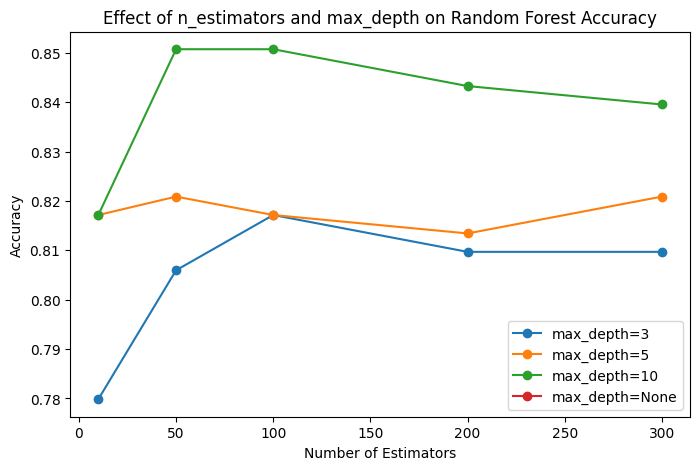

In [25]:
import matplotlib.pyplot as plt

n_estimators_list = [10, 50, 100, 200, 300]
max_depth_list = [3, 5, 10, None]

results = []

for n in n_estimators_list:
    for d in max_depth_list:
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42)
        rf.fit(x_train, y_train)
        y_pred = rf.predict(x_test)
        acc = metrics.accuracy_score(y_test, y_pred)
        results.append((n, d, acc))
        print(f"n_estimators={n}, max_depth={d}, Accuracy={acc:.4f}")

# Convert to DataFrame for easy visualization
results_df = pd.DataFrame(results, columns=['n_estimators', 'max_depth', 'accuracy'])

# Plot effect of n_estimators
plt.figure(figsize=(8,5))
for d in max_depth_list:
    subset = results_df[results_df['max_depth']==d]
    plt.plot(subset['n_estimators'], subset['accuracy'], marker='o', label=f"max_depth={d}")
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Effect of n_estimators and max_depth on Random Forest Accuracy')
plt.legend()
plt.show()

**5.Using RandomForestRegressor and OOB Score**

Task:

Write a program using the RandomForestRegressor model to make predictions on a suitable regression dataset. Enable and observe the oob_score (Out-of-Bag score) parameter.

Interpret the results and explain its significance.

Intermediate Questions:

1. What does the oob_score_ indicate about model performance?
2. How does Out-of-Bag evaluation differ from traditional test-set evaluation?
3. How does the OOB score change with different numbers of trees?

In [26]:
rf = RandomForestRegressor(
    n_estimators=100,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(x_train2, y_train2)
y_pred2 = rf.predict(x_test2)
r2 = r2_score(y_test2, y_pred2)
print("R² Score on Test Data:", r2)
print("OOB Score:", rf.oob_score_)

R² Score on Test Data: -0.15002283982015485
OOB Score: -0.20308750806024745


In [27]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train2, y_train2)
y_pred2 = rf.predict(x_test2)
r2 = r2_score(y_test2, y_pred2)
print("R² Score on Test Data:", r2)
print("OOB Score:", rf.oob_score_)

R² Score on Test Data: -0.3795268899439481
OOB Score: -0.1704297934898742


In [28]:
y_train2_log = np.log1p(y_train2)
y_test2_log = np.log1p(y_test2)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train2, y_train2_log)

y_pred2_log = rf.predict(x_test2)
y_pred2 = np.expm1(y_pred2_log)

r2 = r2_score(y_test2, y_pred2)

print("R² Score on Test Data:", r2)
print("OOB Score (log scale):", rf.oob_score_)


R² Score on Test Data: 0.33702102850260796
OOB Score (log scale): 0.9160186695878534


**6.Exploring Boosting Techniques**

Task:

Write a program to explore different Boosting techniques using suitable datasets:

Adaptive Boosting (AdaBoost) – binary classification,
Gradient Boosting – classification and regression,
XGBoost,
CatBoost.

Write your observations for each model, highlighting how it improves over the previous
iterations and corrects earlier errors.

Intermediate Questions:

1. How does AdaBoost focus on misclassified samples?
2. What makes Gradient Boosting more flexible than AdaBoost?
3. How do XGBoost and CatBoost optimize training speed and accuracy?
4. Which boosting algorithm provided the best trade-off between performance and
computation time?

In [29]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 10.2 MB/s eta 0:00:00


In [30]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, r2_score
from xgboost import XGBRegressor, XGBClassifier
from catboost import CatBoostRegressor, CatBoostClassifier
import warnings
warnings.filterwarnings("ignore")

In [31]:
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.8, random_state=0)
ada.fit(x_train, y_train)
ada_pred = ada.predict(x_test)
ada_acc = accuracy_score(y_test, ada_pred)

gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=0)
gbc.fit(x_train, y_train)
gbc_pred = gbc.predict(x_test)
gbc_acc = accuracy_score(y_test, gbc_pred)

xgbc = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=0, use_label_encoder=False)
xgbc.fit(x_train, y_train)
xgbc_pred = xgbc.predict(x_test)
xgbc_acc = accuracy_score(y_test, xgbc_pred)

catc = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_state=0)
catc.fit(x_train, y_train)
catc_pred = catc.predict(x_test)
catc_acc = accuracy_score(y_test, catc_pred)

print("\n=== Titanic Dataset - Classification ===")
print(f"AdaBoost Accuracy: {ada_acc:.4f}")
print(f"Gradient Boosting Accuracy: {gbc_acc:.4f}")
print(f"XGBoost Accuracy: {xgbc_acc:.4f}")
print(f"CatBoost Accuracy: {catc_acc:.4f}")


=== Titanic Dataset - Classification ===
AdaBoost Accuracy: 0.8022
Gradient Boosting Accuracy: 0.8246
XGBoost Accuracy: 0.8246
CatBoost Accuracy: 0.8209


In [32]:
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=0)
gbr.fit(x_train2, y_train2)
gbr_pred = gbr.predict(x_test2)
gbr_r2 = r2_score(y_test2, gbr_pred)

xgbr = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=0)
xgbr.fit(x_train2, y_train2)
xgbr_pred = xgbr.predict(x_test2)
xgbr_r2 = r2_score(y_test2, xgbr_pred)

catr = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_state=0)
catr.fit(x_train2, y_train2)
catr_pred = catr.predict(x_test2)
catr_r2 = r2_score(y_test2, catr_pred)

print("\n=== Car Price Dataset - Regression ===")
print(f"Gradient Boosting R²: {gbr_r2:.4f}")
print(f"XGBoost R²: {xgbr_r2:.4f}")
print(f"CatBoost R²: {catr_r2:.4f}")


=== Car Price Dataset - Regression ===
Gradient Boosting R²: 0.1138
XGBoost R²: 0.2566
CatBoost R²: 0.2999


**7.Comparative Study of Ensemble Models**

Task:

Apply all ensemble models (Bagging, Random Forest, AdaBoost, Gradient Boosting,
XGBoost, and CatBoost) on the same dataset.

Prepare a detailed report comparing their results based on accuracy, training time, model
interpretability, and overfitting/underfitting behavior.

Intermediate Questions:

1. Which model achieved the best performance?
2. Why did that model perform better than others?
3. What trade-offs (speed, interpretability, complexity) did you observe across models?
4. Which ensemble method would you recommend for large-scale real-world data and
why?

In [33]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

In [34]:
# 1. Bagging
bag = BaggingClassifier(n_estimators=100, random_state=0)
bag.fit(x_train, y_train)
bag_pred = bag.predict(x_test)
bag_acc = accuracy_score(y_test, bag_pred)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)
rf_acc = accuracy_score(y_test, rf_pred)

# 3. AdaBoost
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.8, random_state=0)
ada.fit(x_train, y_train)
ada_pred = ada.predict(x_test)
ada_acc = accuracy_score(y_test, ada_pred)

# 4. Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=0)
gb.fit(x_train, y_train)
gb_pred = gb.predict(x_test)
gb_acc = accuracy_score(y_test, gb_pred)

# 5. XGBoost
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=0, use_label_encoder=False)
xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

# 6. CatBoost
cat = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, verbose=0, random_state=0)
cat.fit(x_train, y_train)
cat_pred = cat.predict(x_test)
cat_acc = accuracy_score(y_test, cat_pred)

# Results comparison
results = pd.DataFrame({
    'Model': ['Bagging', 'Random Forest', 'AdaBoost', 'Gradient Boosting', 'XGBoost', 'CatBoost'],
    'Accuracy': [bag_acc, rf_acc, ada_acc, gb_acc, xgb_acc, cat_acc]
})

print("=== Ensemble Model Comparison on Titanic Dataset ===")
print(results.sort_values(by='Accuracy', ascending=False).to_string(index=False))

=== Ensemble Model Comparison on Titanic Dataset ===
            Model  Accuracy
          Bagging  0.824627
Gradient Boosting  0.824627
          XGBoost  0.824627
         CatBoost  0.820896
    Random Forest  0.809701
         AdaBoost  0.802239


**8. Visualizing the Ensemble models**

* Visualize decision boundaries of ensemble models.
* Compare ensemble performance under noisy or missing data.
* \Analyze feature importance across different ensemble algorithms.

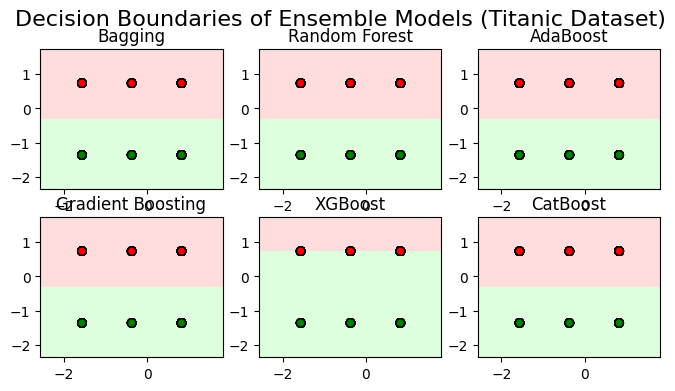

In [50]:
from matplotlib.colors import ListedColormap

# Scale features for smooth visualization
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

# We'll visualize using only two features (for clarity)
X_vis = X_scaled[:, :2]  # e.g., Pclass and Sex (scaled)
x_train_v, x_test_v, y_train_v, y_test_v = train_test_split(X_vis, y, test_size=0.3, random_state=0)

# Define models
models = {
    'Bagging': BaggingClassifier(n_estimators=50, random_state=0),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=0),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=0),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=0),
    'XGBoost': XGBClassifier(n_estimators=50, use_label_encoder=False, eval_metric='logloss', random_state=0),
    'CatBoost': CatBoostClassifier(iterations=50, learning_rate=0.1, depth=4, verbose=0, random_state=0)
}

# Step 2: Visualize Decision Boundaries
plt.figure(figsize=(8, 4))
cmap = ListedColormap(['#FFAAAA', '#AAFFAA'])

for i, (name, model) in enumerate(models.items(), 1):
    model.fit(x_train_v, y_train_v)
    x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
    y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.subplot(2, 3, i)
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap)
    plt.scatter(x_test_v[:, 0], x_test_v[:, 1], c=y_test_v, edgecolor='k', cmap=ListedColormap(['red', 'green']))
    plt.title(name)

plt.suptitle("Decision Boundaries of Ensemble Models (Titanic Dataset)", fontsize=16)
plt.show()

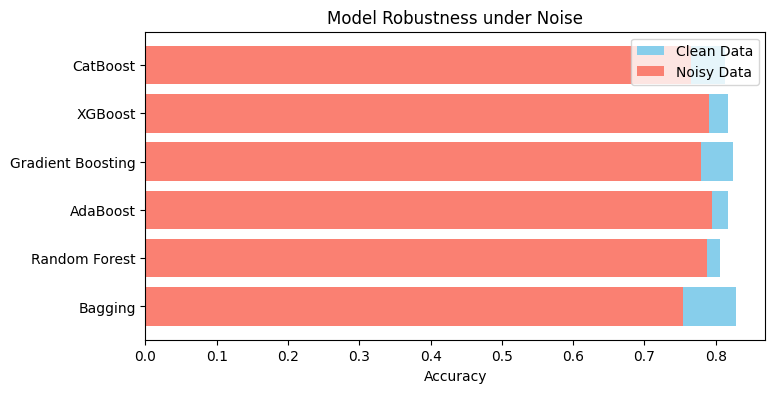

In [49]:
def add_noise(data, noise_level=0.2):
    noisy_data = data.copy()
    n_samples, n_features = data.shape
    num_noisy = int(noise_level * n_samples * n_features)
    idx = np.random.choice(n_samples * n_features, num_noisy, replace=False)
    flat = noisy_data.flatten()
    flat[idx] = np.random.randn(len(idx)) * flat.std()
    return flat.reshape(data.shape)

X_noisy = add_noise(X_scaled, 0.2)
x_train_n, x_test_n, y_train_n, y_test_n = train_test_split(X_noisy, y, test_size=0.3, random_state=0)

accuracies_clean = {}
accuracies_noisy = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    acc_clean = model.score(x_test, y_test)
    model.fit(x_train_n, y_train_n)
    acc_noisy = model.score(x_test_n, y_test_n)
    accuracies_clean[name] = acc_clean
    accuracies_noisy[name] = acc_noisy

plt.figure(figsize=(8,4))
plt.barh(list(models.keys()), accuracies_clean.values(), label='Clean Data', color='skyblue')
plt.barh(list(models.keys()), accuracies_noisy.values(), label='Noisy Data', color='salmon')
plt.xlabel('Accuracy')
plt.title('Model Robustness under Noise')
plt.legend()
plt.show()

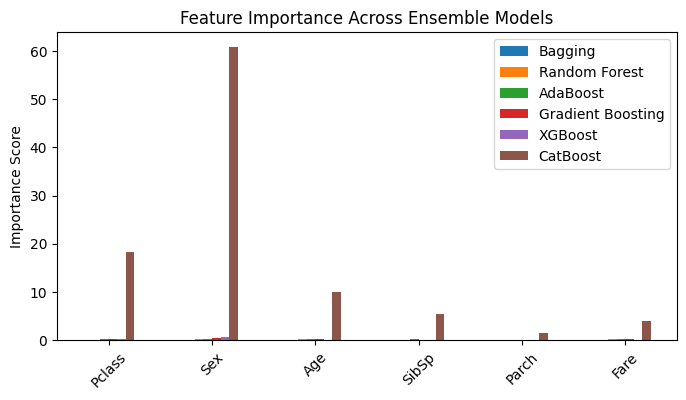

In [51]:
feature_importances = pd.DataFrame(index=X.columns)

for name, model in models.items():
    model.fit(x_train, y_train)
    if hasattr(model, 'feature_importances_'):
        feature_importances[name] = model.feature_importances_
    else:
        feature_importances[name] = np.nan  # Some models may not expose feature_importances_

feature_importances.plot(kind='bar', figsize=(8,4))
plt.title("Feature Importance Across Ensemble Models")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.show()

**9.Exploring Heterogeneous Ensemble Models**

Task:

Write a program to build a Heterogeneous Ensemble, combining different types of
classifiers such as Decision Tree, K-Nearest Neighbors, Logistic Regression, and
Support Vector Machine (SVM) using a VotingClassifier.

Compare the results with homogeneous ensembles.

Intermediate Questions:

1. What makes an ensemble heterogeneous?
2. How does model diversity influence the final performance?
3. Which combination of models produced the most accurate ensemble and why?
4. How does the voting method (hard vs. soft) impact the heterogeneous ensemble
outcome?

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

# Define base models
dt = DecisionTreeClassifier(random_state=0)
knn = KNeighborsClassifier()
lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)

# Hard Voting Ensemble
voting_hard = VotingClassifier(
    estimators=[('dt', dt), ('knn', knn), ('lr', lr), ('svm', svm)],
    voting='hard'
)

# Soft Voting Ensemble
voting_soft = VotingClassifier(
    estimators=[('dt', dt), ('knn', knn), ('lr', lr), ('svm', svm)],
    voting='soft'
)

# Train & Evaluate
voting_hard.fit(x_train, y_train)
voting_soft.fit(x_train, y_train)

hard_acc = accuracy_score(y_test, voting_hard.predict(x_test))
soft_acc = accuracy_score(y_test, voting_soft.predict(x_test))

print("Hard Voting Accuracy:", hard_acc)
print("Soft Voting Accuracy:", soft_acc)

Hard Voting Accuracy: 0.7873134328358209
Soft Voting Accuracy: 0.8283582089552238


In [39]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier

rf = RandomForestClassifier(random_state=0)
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=0)
ada = AdaBoostClassifier(random_state=0)

models = [rf, bag, ada]
for model in models:
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    print(model.__class__.__name__, accuracy_score(y_test, pred))


RandomForestClassifier 0.8097014925373134
BaggingClassifier 0.8134328358208955
AdaBoostClassifier 0.8171641791044776


**10. Homogeneous vs. Heterogeneous Ensembles – A Comparative Study**

Task:

Apply both homogeneous and heterogeneous ensemble techniques (Bagging, Random
Forest, Voting, Stacking) on the same dataset.

Prepare a summary comparing their performance, computational complexity,
interpretability, and robustness.

Intermediate Questions:

1. Which type of ensemble performed best overall and why?
2. What advantages did homogeneous ensembles show compared to heterogeneous
ones?
3. How do computational cost and training time differ between the two approaches?
4. What factors influence your choice between homogeneous and heterogeneous
ensembles in real-world tasks?

In [40]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

bag = BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=0)
bag.fit(x_train, y_train)
bag_acc = accuracy_score(y_test, bag.predict(x_test))
print("Bagging Accuracy:", bag_acc)

Bagging Accuracy: 0.8134328358208955


In [41]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0)
rf.fit(x_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(x_test))
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8097014925373134


In [42]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

dt = DecisionTreeClassifier(random_state=0)
knn = KNeighborsClassifier()
lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True)

voting_hard = VotingClassifier(
    estimators=[('dt', dt), ('knn', knn), ('lr', lr), ('svm', svm)],
    voting='hard'
)
voting_soft = VotingClassifier(
    estimators=[('dt', dt), ('knn', knn), ('lr', lr), ('svm', svm)],
    voting='soft'
)

voting_hard.fit(x_train, y_train)
voting_soft.fit(x_train, y_train)

vh_acc = accuracy_score(y_test, voting_hard.predict(x_test))
vs_acc = accuracy_score(y_test, voting_soft.predict(x_test))

print("Voting (Hard) Accuracy:", vh_acc)
print("Voting (Soft) Accuracy:", vs_acc)

Voting (Hard) Accuracy: 0.7873134328358209
Voting (Soft) Accuracy: 0.8283582089552238


In [43]:
from sklearn.ensemble import StackingClassifier

base_models = [
    ('dt', DecisionTreeClassifier(random_state=0)),
    ('knn', KNeighborsClassifier()),
    ('lr', LogisticRegression(max_iter=1000))
]

meta_model = RandomForestClassifier(random_state=0)

stack = StackingClassifier(estimators=base_models, final_estimator=meta_model)

stack.fit(x_train, y_train)
stack_acc = accuracy_score(y_test, stack.predict(x_test))
print("Stacking Accuracy:", stack_acc)

Stacking Accuracy: 0.7425373134328358


In [44]:
print("\n=== HOMOGENEOUS ENSEMBLES ===")
print("Bagging:", bag_acc)
print("Random Forest:", rf_acc)

print("\n=== HETEROGENEOUS ENSEMBLES ===")
print("Voting (Hard):", vh_acc)
print("Voting (Soft):", vs_acc)
print("Stacking:", stack_acc)


=== HOMOGENEOUS ENSEMBLES ===
Bagging: 0.8134328358208955
Random Forest: 0.8097014925373134

=== HETEROGENEOUS ENSEMBLES ===
Voting (Hard): 0.7873134328358209
Voting (Soft): 0.8283582089552238
Stacking: 0.7425373134328358
